In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

**<font size="10" color="red">ch4_RNN(Recurrent Neural Network 순환신경망)</font>**
# 1.문맥을 이용하여 모델만들기

In [6]:
text ="""경마장에 있는 말이 뛰고있다
그의 말이 법이다
가는 말이 고와야 오는말이 곱다"""
text1 = "겨울이 오는 날"

In [7]:
from keras_preprocessing.text import Tokenizer
t = Tokenizer()
t.fit_on_texts([text, text1])
encoded = t.texts_to_sequences([text, text1])
print(encoded)
print(t.word_index)

[[2, 3, 1, 4, 5, 1, 6, 7, 1, 8, 9, 10], [11, 12, 13]]
{'말이': 1, '경마장에': 2, '있는': 3, '뛰고있다': 4, '그의': 5, '법이다': 6, '가는': 7, '고와야': 8, '오는말이': 9, '곱다': 10, '겨울이': 11, '오는': 12, '날': 13}


In [9]:
text = """경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다"""

In [10]:
# 문자를 인덱스시퀀스로 변환하기 위한 과정
t = Tokenizer()
t.fit_on_texts([text])
print(t.word_index)

{'말이': 1, '경마장에': 2, '있는': 3, '뛰고': 4, '있다': 5, '그의': 6, '법이다': 7, '가는': 8, '고와야': 9, '오는': 10, '곱다': 11}


In [11]:
# 문자열 리스트를 인덱스 시퀀스로 변환
print(t.texts_to_sequences(['경마장에 말이 있다', '말이 뛴다']))
print(t.texts_to_sequences(['가는 말이 곱다'])[0])

[[2, 1, 5], [1]]
[8, 1, 11]


In [12]:
for key, value in t.word_index.items():
    print(key, value)

말이 1
경마장에 2
있는 3
뛰고 4
있다 5
그의 6
법이다 7
가는 8
고와야 9
오는 10
곱다 11


In [13]:
text = """경마장에 있는 말이 뛰고 있다
그의 말이 법이다
가는 말이 고와야 오는 말이 곱다"""

In [14]:
# text를 학습시키기 위한 ['경마장에 있는', '경마장에 있는 말이', ....]
sequences = []
for line in text.split('\n'):
    print('원 문장 : ',line)
    encoded = t.texts_to_sequences([line])[0]
    print('encoded된 문장 :', encoded)
    for i in range(0, len(encoded)-1): # 시작index
        for j in range(i+2, len(encoded)+1 ): # 끝나는 index
            sequences.append(encoded[i:j])
#sequences
print('sequences와 해석 출력')
for sequence in sequences:
    # print(sequence)
    for word_seq in sequence:
        for key, value in t.word_index.items():
            if word_seq==value:
                print("{}:{}".format(word_seq, key), end=' ')
                break
    print()


원 문장 :  경마장에 있는 말이 뛰고 있다
encoded된 문장 : [2, 3, 1, 4, 5]
원 문장 :  그의 말이 법이다
encoded된 문장 : [6, 1, 7]
원 문장 :  가는 말이 고와야 오는 말이 곱다
encoded된 문장 : [8, 1, 9, 10, 1, 11]
sequences와 해석 출력
2:경마장에 3:있는 
2:경마장에 3:있는 1:말이 
2:경마장에 3:있는 1:말이 4:뛰고 
2:경마장에 3:있는 1:말이 4:뛰고 5:있다 
3:있는 1:말이 
3:있는 1:말이 4:뛰고 
3:있는 1:말이 4:뛰고 5:있다 
1:말이 4:뛰고 
1:말이 4:뛰고 5:있다 
4:뛰고 5:있다 
6:그의 1:말이 
6:그의 1:말이 7:법이다 
1:말이 7:법이다 
8:가는 1:말이 
8:가는 1:말이 9:고와야 
8:가는 1:말이 9:고와야 10:오는 
8:가는 1:말이 9:고와야 10:오는 1:말이 
8:가는 1:말이 9:고와야 10:오는 1:말이 11:곱다 
1:말이 9:고와야 
1:말이 9:고와야 10:오는 
1:말이 9:고와야 10:오는 1:말이 
1:말이 9:고와야 10:오는 1:말이 11:곱다 
9:고와야 10:오는 
9:고와야 10:오는 1:말이 
9:고와야 10:오는 1:말이 11:곱다 
10:오는 1:말이 
10:오는 1:말이 11:곱다 
1:말이 11:곱다 


In [16]:
# sequences의 길이를 모두 같게(padding)
my_len = max([len(seq) for seq in sequences])
my_len


6

In [17]:
# sequences를 훈련 가능하도록 6개(앞에 0, 뒤에 0)
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(sequences=sequences,
                                maxlen=my_len,
                                padding='pre', # 앞에 0을 padding
                                #truncating='post',
                                )
padded_sequences[:3], padded_sequences.shape

(array([[0, 0, 0, 0, 2, 3],
        [0, 0, 0, 2, 3, 1],
        [0, 0, 2, 3, 1, 4]]),
 (28, 6))

In [18]:
# 독립변수(X)와 타겟변수(y)를 분리
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
# 단어 갯수
vocab_size = len(t.word_index)
vocab_size

11

In [19]:
# 종속변수의 원핫인코딩
from tensorflow.keras.utils import to_categorical
Y = to_categorical(y, vocab_size+1)
Y[:3]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [20]:
X.shape, Y.shape, vocab_size

((28, 5), (28, 12), 11)

In [21]:
# 모델 생성 ( Embedding -> RNN -> Dense층 )
# Embedding층의 입력은 12(희소행렬) -> 출력은 10. 이 단계에서 필요한 Embedding weight matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
# 교안 106p.
model = Sequential(name='sequential')
model.add(Embedding(input_dim=vocab_size+1, # 임베딩 입력
                   output_dim=10, # 임베딩 출력
                   input_length=X.shape[1])) # 입력(독립)변수 단어 길이
model.add(SimpleRNN(32, activation='tanh')) # 기본 activation='tanh'
model.add(Dense(12, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 10)             120       
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1376      
                                                                 
 dense (Dense)               (None, 12)                396       
                                                                 
Total params: 1,892
Trainable params: 1,892
Non-trainable params: 0
_________________________________________________________________


In [22]:
# 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 학습시키기
hist = model.fit(X, Y, epochs=300, verbose=2)

Epoch 1/300
1/1 - 1s - loss: 2.4943 - accuracy: 0.0000e+00 - 1s/epoch - 1s/step
Epoch 2/300
1/1 - 0s - loss: 2.4807 - accuracy: 0.0357 - 5ms/epoch - 5ms/step
Epoch 3/300
1/1 - 0s - loss: 2.4673 - accuracy: 0.1071 - 4ms/epoch - 4ms/step
Epoch 4/300
1/1 - 0s - loss: 2.4540 - accuracy: 0.1429 - 0s/epoch - 0s/step
Epoch 5/300
1/1 - 0s - loss: 2.4407 - accuracy: 0.2143 - 0s/epoch - 0s/step
Epoch 6/300
1/1 - 0s - loss: 2.4272 - accuracy: 0.2500 - 16ms/epoch - 16ms/step
Epoch 7/300
1/1 - 0s - loss: 2.4135 - accuracy: 0.2857 - 0s/epoch - 0s/step
Epoch 8/300
1/1 - 0s - loss: 2.3993 - accuracy: 0.2857 - 4ms/epoch - 4ms/step
Epoch 9/300
1/1 - 0s - loss: 2.3847 - accuracy: 0.2857 - 0s/epoch - 0s/step
Epoch 10/300
1/1 - 0s - loss: 2.3696 - accuracy: 0.2857 - 0s/epoch - 0s/step
Epoch 11/300
1/1 - 0s - loss: 2.3539 - accuracy: 0.2857 - 3ms/epoch - 3ms/step
Epoch 12/300
1/1 - 0s - loss: 2.3375 - accuracy: 0.2857 - 2ms/epoch - 2ms/step
Epoch 13/300
1/1 - 0s - loss: 2.3205 - accuracy: 0.2857 - 10ms/epoc

Epoch 106/300
1/1 - 0s - loss: 1.0657 - accuracy: 0.6786 - 0s/epoch - 0s/step
Epoch 107/300
1/1 - 0s - loss: 1.0548 - accuracy: 0.6786 - 14ms/epoch - 14ms/step
Epoch 108/300
1/1 - 0s - loss: 1.0441 - accuracy: 0.6786 - 0s/epoch - 0s/step
Epoch 109/300
1/1 - 0s - loss: 1.0336 - accuracy: 0.6786 - 0s/epoch - 0s/step
Epoch 110/300
1/1 - 0s - loss: 1.0233 - accuracy: 0.6786 - 16ms/epoch - 16ms/step
Epoch 111/300
1/1 - 0s - loss: 1.0131 - accuracy: 0.6786 - 0s/epoch - 0s/step
Epoch 112/300
1/1 - 0s - loss: 1.0032 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 113/300
1/1 - 0s - loss: 0.9934 - accuracy: 0.7143 - 4ms/epoch - 4ms/step
Epoch 114/300
1/1 - 0s - loss: 0.9837 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 115/300
1/1 - 0s - loss: 0.9743 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 116/300
1/1 - 0s - loss: 0.9650 - accuracy: 0.7143 - 0s/epoch - 0s/step
Epoch 117/300
1/1 - 0s - loss: 0.9558 - accuracy: 0.7143 - 17ms/epoch - 17ms/step
Epoch 118/300
1/1 - 0s - loss: 0.9468 - accuracy: 

1/1 - 0s - loss: 0.4686 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 210/300
1/1 - 0s - loss: 0.4655 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 211/300
1/1 - 0s - loss: 0.4624 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 212/300
1/1 - 0s - loss: 0.4593 - accuracy: 0.8214 - 17ms/epoch - 17ms/step
Epoch 213/300
1/1 - 0s - loss: 0.4562 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 214/300
1/1 - 0s - loss: 0.4532 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 215/300
1/1 - 0s - loss: 0.4502 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 216/300
1/1 - 0s - loss: 0.4472 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 217/300
1/1 - 0s - loss: 0.4443 - accuracy: 0.8214 - 16ms/epoch - 16ms/step
Epoch 218/300
1/1 - 0s - loss: 0.4414 - accuracy: 0.8214 - 0s/epoch - 0s/step
Epoch 219/300
1/1 - 0s - loss: 0.4385 - accuracy: 0.8214 - 15ms/epoch - 15ms/step
Epoch 220/300
1/1 - 0s - loss: 0.4356 - accuracy: 0.8571 - 4ms/epoch - 4ms/step
Epoch 221/300
1/1 - 0s - loss: 0.4328 - accuracy: 0.8571 - 0s/ep

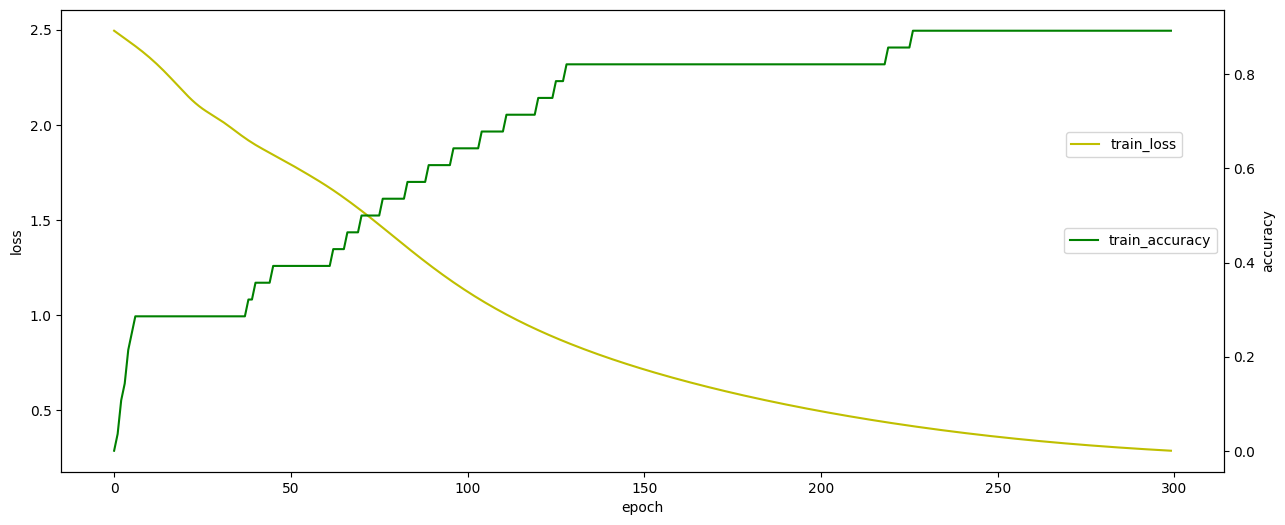

In [23]:
# 학습과정 살펴보기(시각화)
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [24]:
# 모델 사용하기(경마장에 있는 -> 말이)
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoded = t.texts_to_sequences(['6시가 되면'])[0]
input_data = pad_sequences([encoded], maxlen=5, padding='pre')
print('모델에 들어갈 입력 데이터 :',input_data)
result = model.predict(input_data).argmax(axis=1)[0]
print('모델 예측 결과 :', result)
for key, value in t.word_index.items():
    if value==result:
        print('가장 확률이 높은 단어(예측된 단어) :', key)
        break

모델에 들어갈 입력 데이터 : [[0 0 0 0 0]]
1/1 [==============================] - 0s 261ms/step
모델 예측 결과 : 1
가장 확률이 높은 단어(예측된 단어) : 말이


# 2. 다음 문맥 예측해보기

In [25]:
# '가는 말이' 이후에 올 단어 4개 예측
def sentence_generation(model, t, current_word, n):
    print('입력된 단어 :', current_word)
    for i in range(1, n+1):
        encoded = t.texts_to_sequences([current_word])[0]
        input_data = pad_sequences([encoded], maxlen=5, padding='pre')
        result = model.predict(input_data, verbose=0).argmax(axis=1)[0]
        for key, value in t.word_index.items():
            if value==result:
                print(f'{i}번째 {key}:{result}')
                current_word = current_word + ' ' + key
                break
    return current_word

In [26]:
sentence_generation(model, t, '경마장에', 4)

입력된 단어 : 경마장에
1번째 있는:3
2번째 말이:1
3번째 뛰고:4
4번째 있다:5


'경마장에 있는 말이 뛰고 있다'